In [ ]:
%load_ext autoreload
%autoreload 2

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.stats import anderson_ksamp
import mlflow
import torch
from torch import nn, optim
import torch.utils.data as data_utils
from IPython.display import clear_output
from utils import *

In [ ]:
df = pd.read_csv('data/df_train.csv')
df = df.set_index('dates')

In [ ]:
params = np.load('parameters/example_params.npy')
noise = np.load('data/noise.npy')

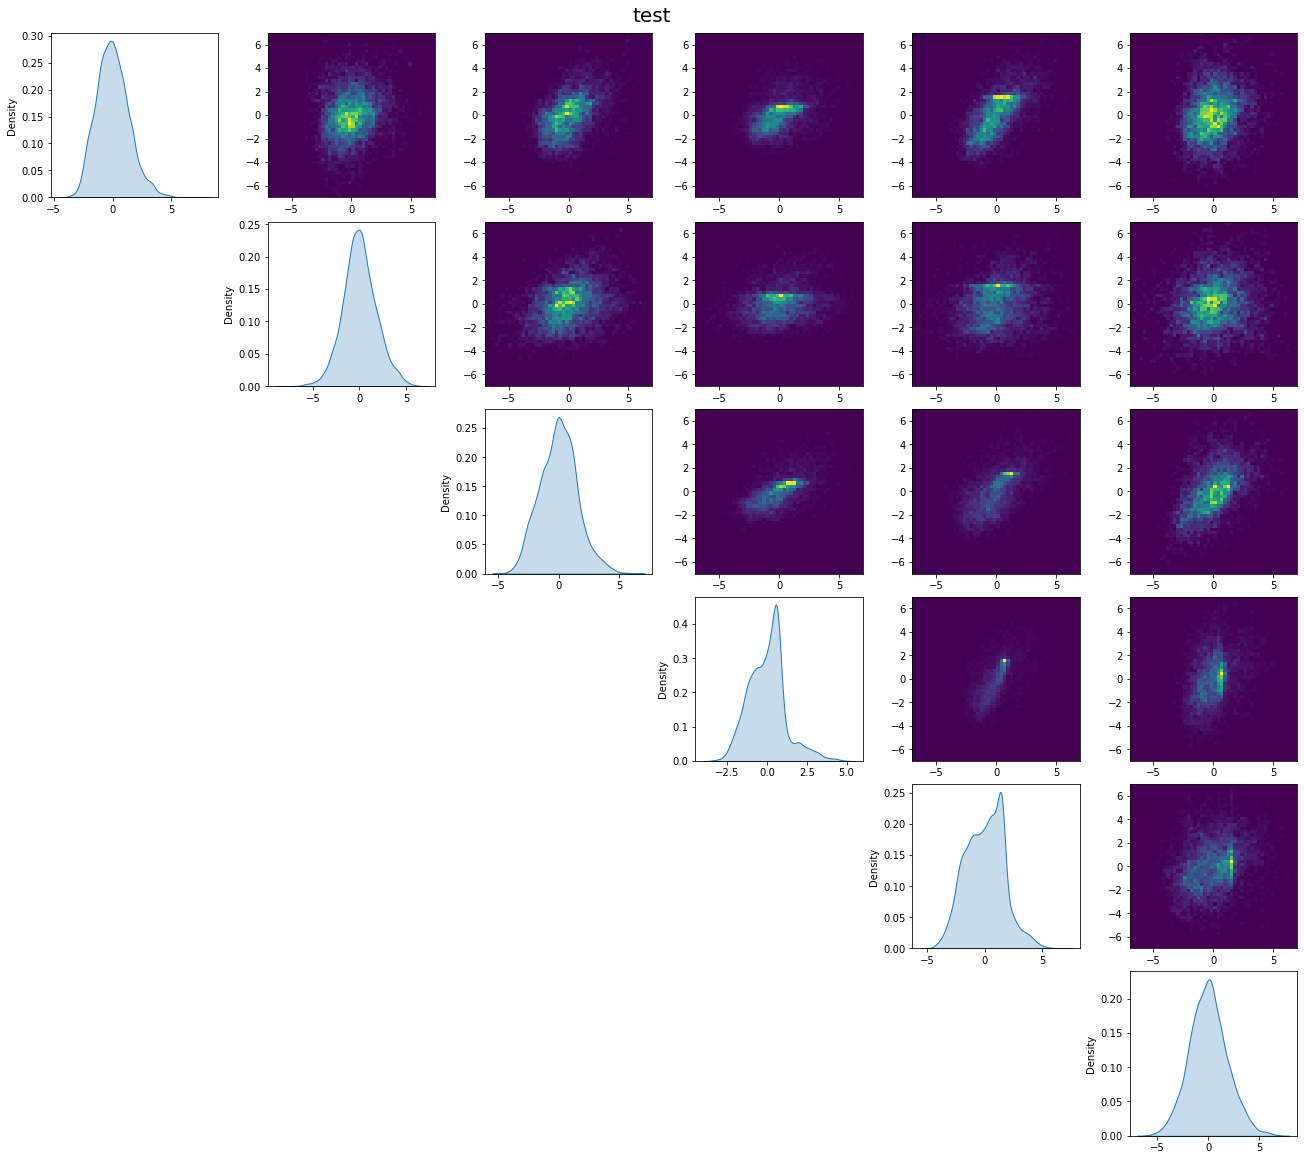

In [31]:
fig, ax = plt.subplots(nrows=6, ncols=6, figsize=(18, 16), constrained_layout=True)
fig.suptitle('test', fontsize=20)

for i in range(6):
    for j in range(6):
        if i < j:
            ax[i][j].hist2d(df[f's{i+1}'], df[f's{j+1}'], bins=50, range=[[-7, 7], [-7, 7]])
        if i > j:
            fig.delaxes(ax[i][j])
    sns.kdeplot(data=df.to_numpy()[:, i], ax=ax[i][i], fill=True)


# Normalized flows

In [32]:
from models import MAF


In [52]:
args = {
    'n_layers': 10,
    'n_epochs': 100,
    'n_dim': 6,
    'n_hidden_features': 32,
    'batch_size': 32,
    'lr': 1e-3,
}

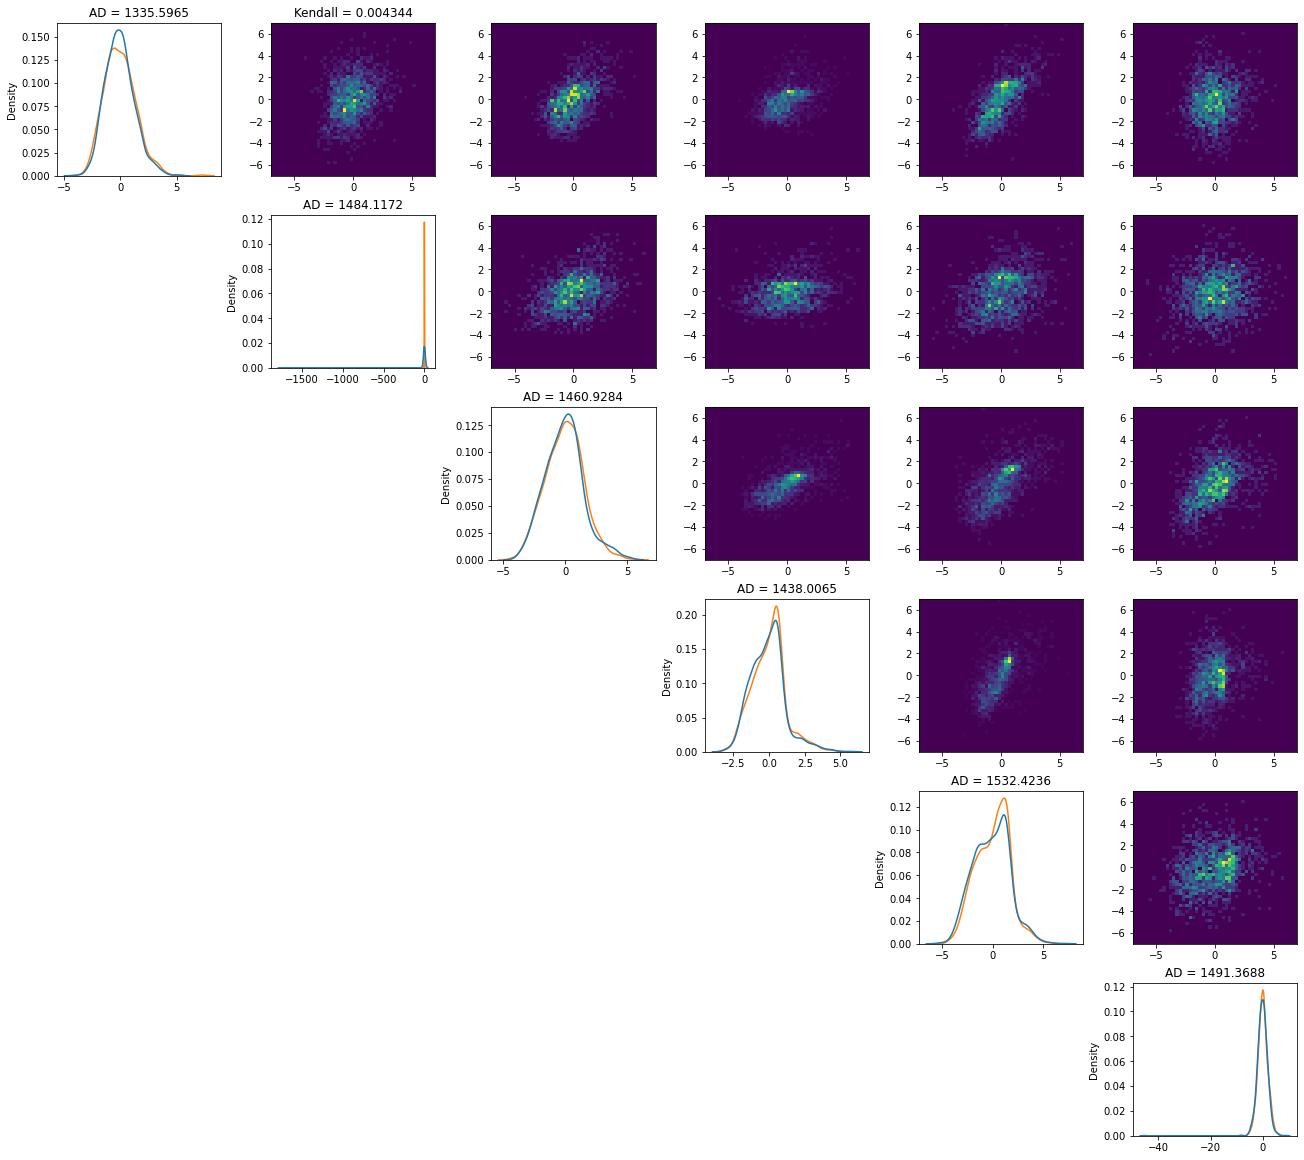

Kendall:  0.0089; AD:  1458.56: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [03:47<00:00,  2.28s/it]


Test Kendall:     0.0047
Test AD:         2372.37


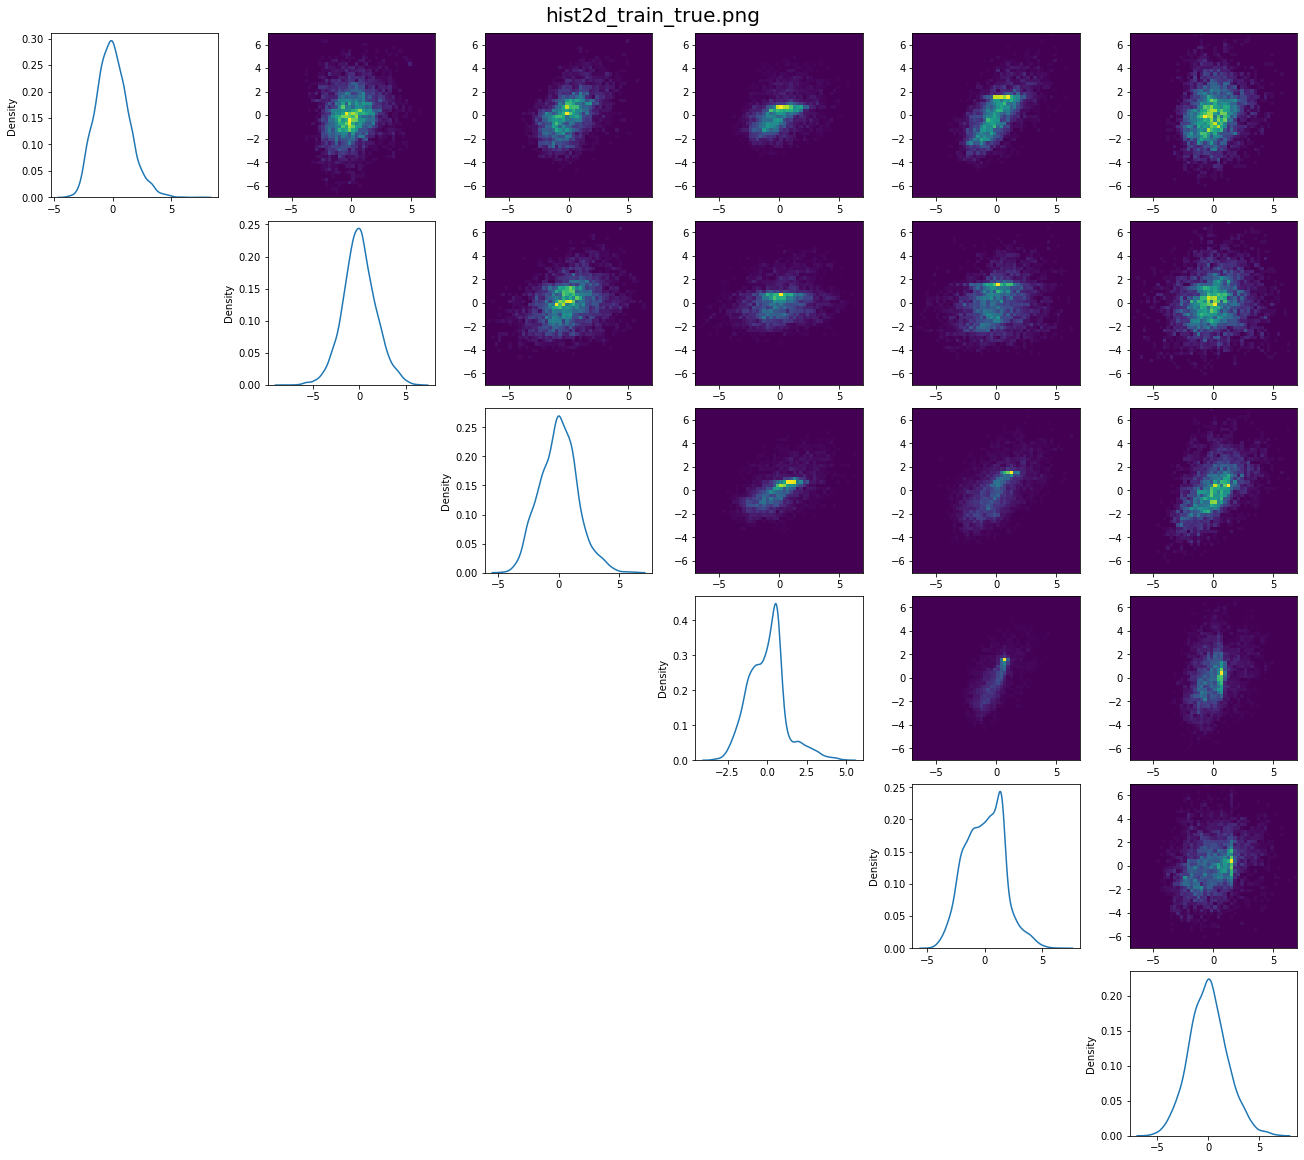

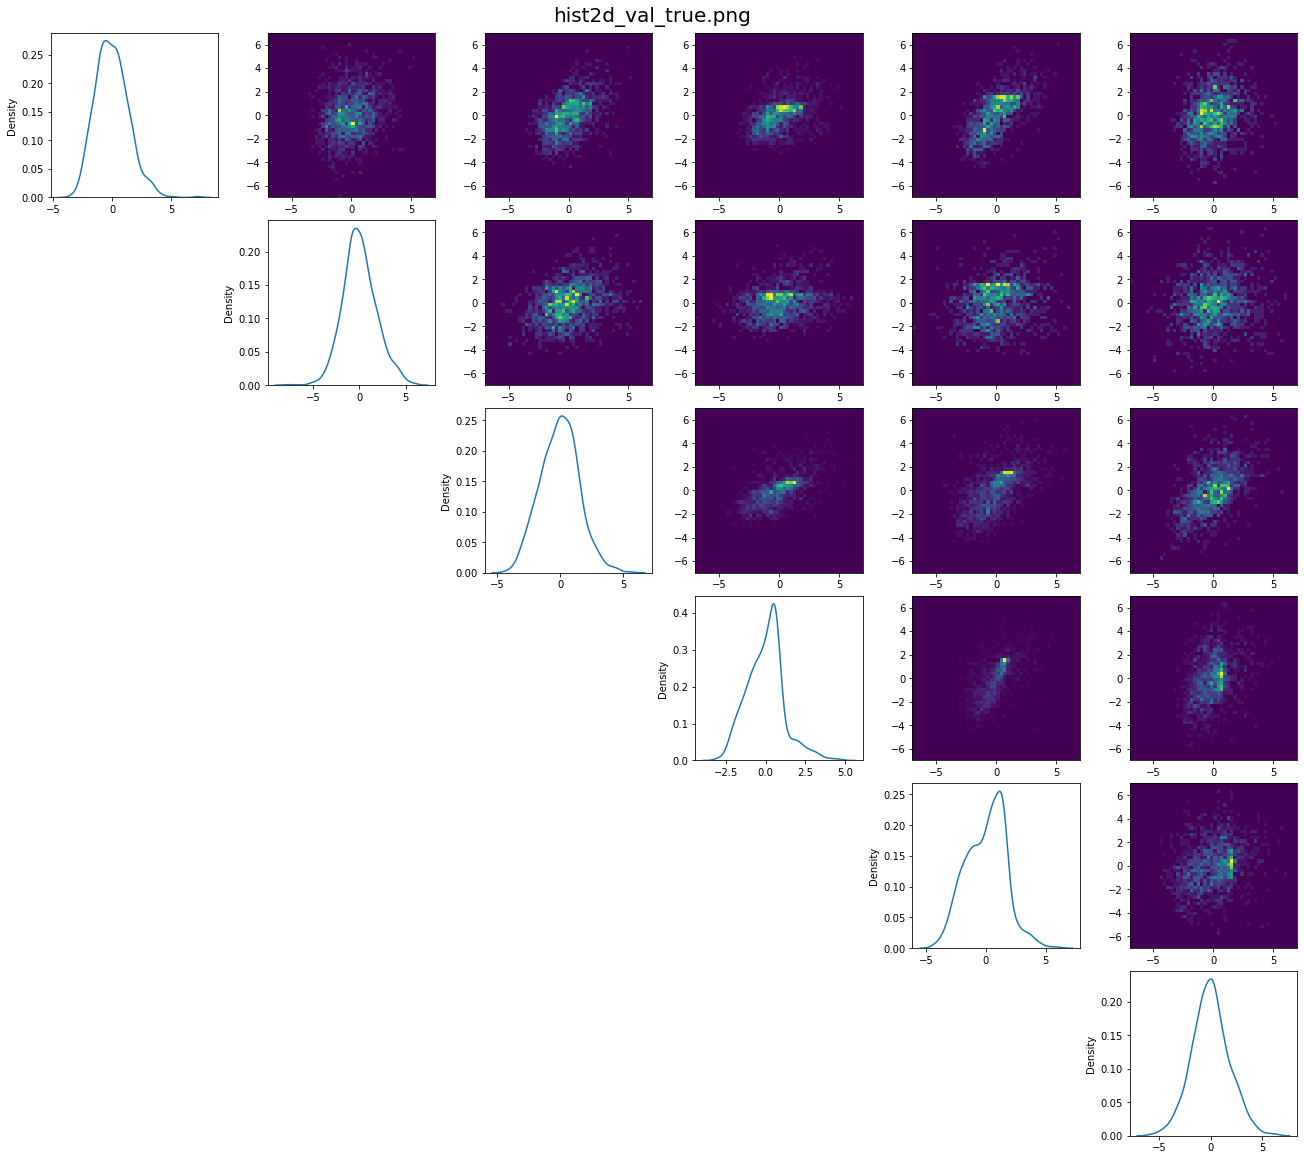

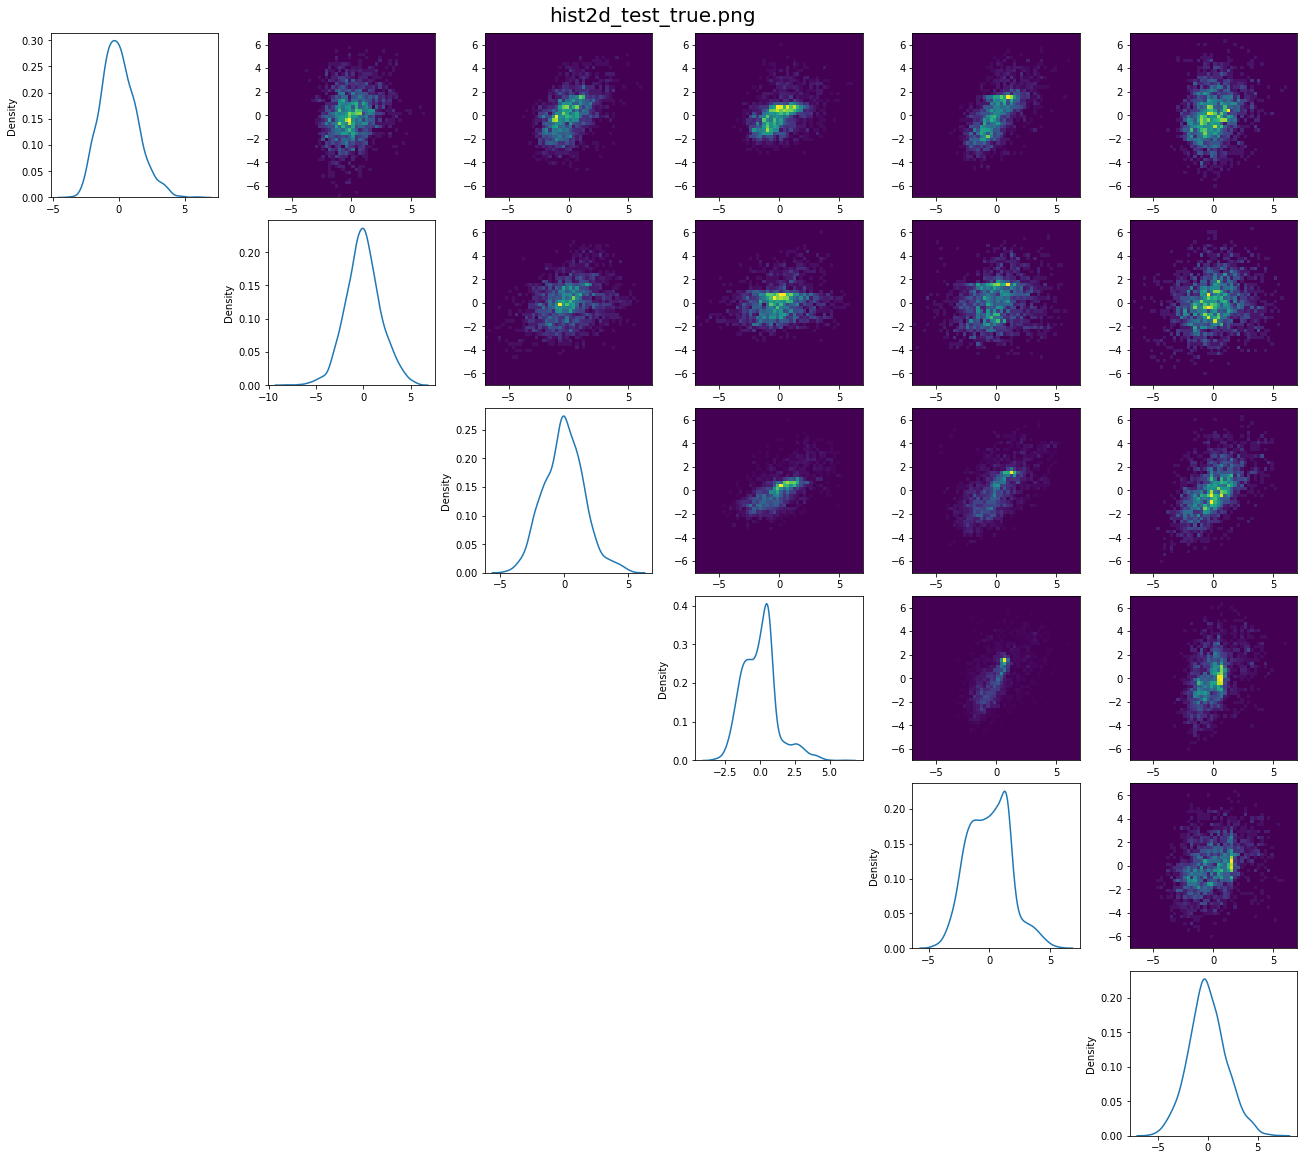

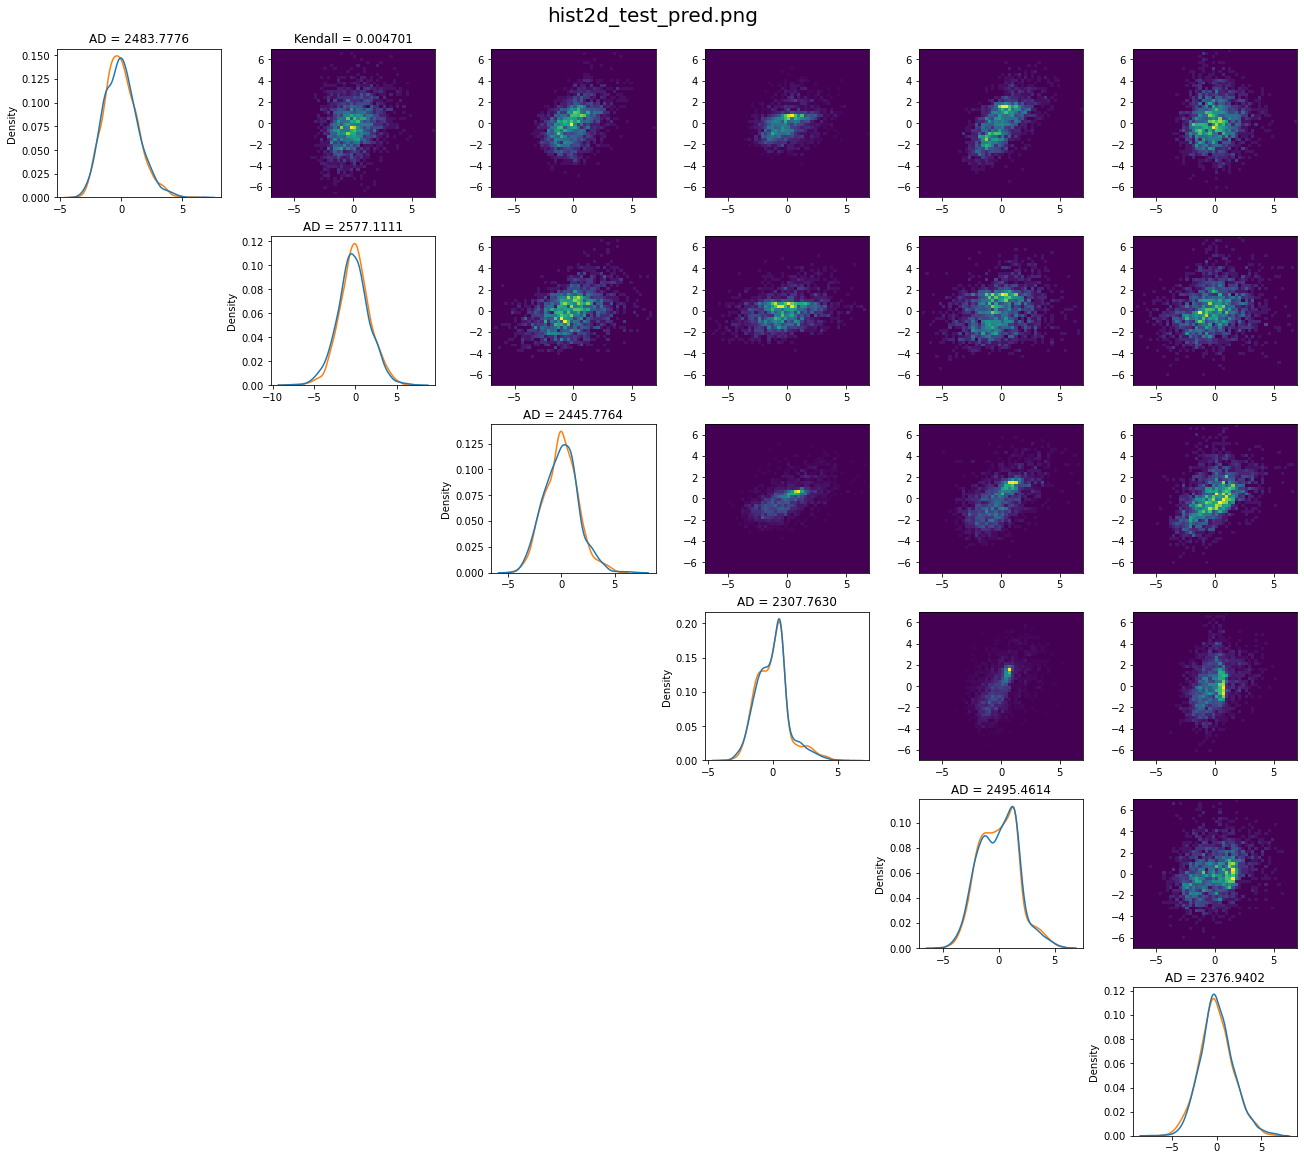

In [53]:
np.random.seed(1337)

with mlflow.start_run() as run:
    
    class MyMAF(MAF):
        def on_train_epoch_end(self):
            X_val_pred = self.sample(self.model, len(self.X_val))
            fig = plot_hist2d(X_val_pred, self.X_val)
            clear_output(wait=True)
            plt.show()
        
    trainer = MyMAF(args, run.info.run_id)
    mlflow.log_params(args)
    trainer.train()
    
    kendall, ad_mean = trainer.test_step()
    print(f"Test Kendall: {kendall:10.4f}")
    print(f"Test AD:      {ad_mean:10.2f}")
